# Energy Consumption Time Series Forecasting

**Objective:** Forecast short-term household energy usage using historical time-based patterns.

**Dataset:** Household Power Consumption Dataset

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from prophet import Prophet  # updated
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

## Step 2: Load Dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Load dataset safely
file_path = r'C:\Users\alpha\Desktop\energy_cunsumption\Household_power_consumption.csv'

data = pd.read_csv(file_path, sep=';', low_memory=False, na_values=['?'])

# Step 2: Combine Date & Time into datetime column
data['datetime'] = pd.to_datetime(data['Date'] + ' ' + data['Time'], errors='coerce')

# Step 3: Drop rows where datetime could not be parsed
data = data.dropna(subset=['datetime'])

# Step 4: Set datetime as index
data.set_index('datetime', inplace=True)

# Step 5: Convert 'Global_active_power' to numeric (NaN if not convertible)
data['Global_active_power'] = pd.to_numeric(data['Global_active_power'], errors='coerce')

# Step 6: Drop rows where 'Global_active_power' is NaN
data = data.dropna(subset=['Global_active_power'])

# Step 7: Resample to hourly data
data_hourly = data['Global_active_power'].resample('H').mean()

# Step 8: Interpolate missing values (if any after resampling)
data_hourly = data_hourly.interpolate(method='time')

# Step 9: Plot first 7 days of available data
data_hourly.iloc[:24*7].plot(figsize=(15,5), title='Hourly Energy Consumption (First 7 Days)')
plt.ylabel('Global Active Power (kilowatts)')
plt.show()

# Step 10: Print first 5 rows to confirm
print(data_hourly.head())

## Step 3: Resample and Handle Missing Values

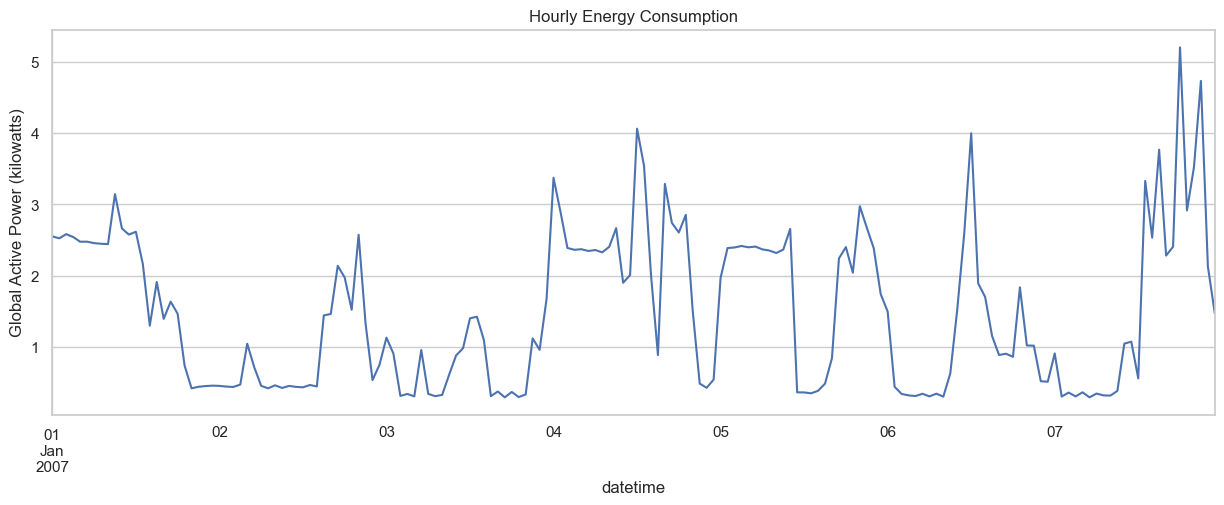

In [16]:
# Resample to hourly data
data_hourly = data['Global_active_power'].resample('h').mean()

# Fill missing values with interpolation
data_hourly = data_hourly.interpolate(method='time')

# Plot a sample
data_hourly['2007-01-01':'2007-01-07'].plot(figsize=(15,5), title='Hourly Energy Consumption')
plt.ylabel('Global Active Power (kilowatts)')
plt.show()

## Step 4: Feature Engineering

In [ ]:
# Create time-based features
df_features = pd.DataFrame()
df_features['y'] = data_hourly
df_features['hour'] = data_hourly.index.hour
df_features['dayofweek'] = data_hourly.index.dayofweek
df_features['month'] = data_hourly.index.month
df_features['is_weekend'] = data_hourly.index.dayofweek.isin([5,6]).astype(int)

df_features.head()

## Step 5: Train-Test Split

In [18]:
train_size = int(len(df_features)*0.8)
train = df_features.iloc[:train_size]
test = df_features.iloc[train_size:]

X_train = train[['hour','dayofweek','month','is_weekend']]
y_train = train['y']
X_test = test[['hour','dayofweek','month','is_weekend']]
y_test = test['y']

## Step 6: ARIMA Model

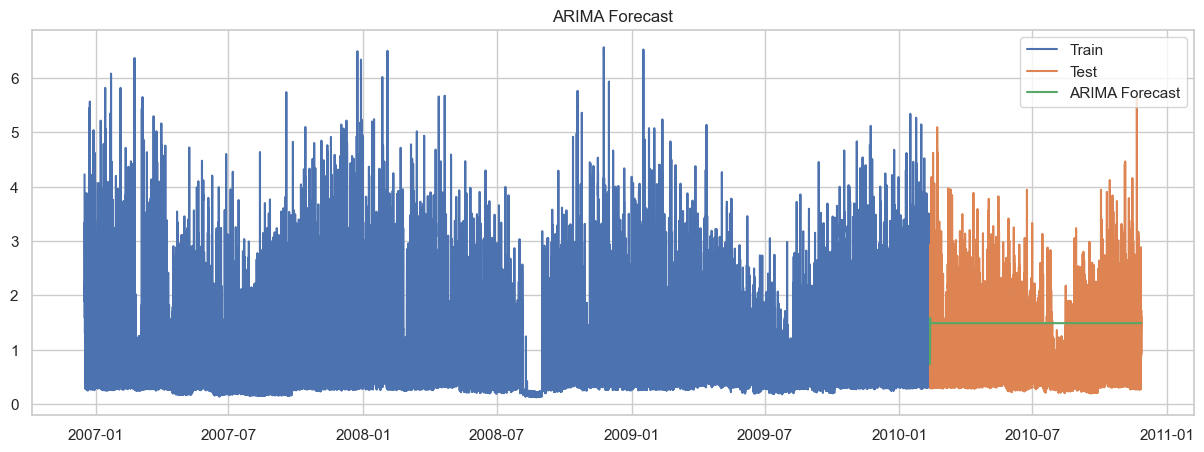

ARIMA RMSE: 0.876


In [19]:
# Fit ARIMA model
arima_model = ARIMA(train['y'], order=(5,1,2))
arima_result = arima_model.fit()

# Forecast
arima_forecast = arima_result.forecast(steps=len(test))

# Plot
plt.figure(figsize=(15,5))
plt.plot(train['y'], label='Train')
plt.plot(test['y'], label='Test')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast')
plt.legend()
plt.title('ARIMA Forecast')
plt.show()

# Evaluate
arima_rmse = np.sqrt(mean_squared_error(test['y'], arima_forecast))
print(f"ARIMA RMSE: {arima_rmse:.3f}")

## Step 7: Prophet Model

06:09:41 - cmdstanpy - INFO - Chain [1] start processing
06:10:02 - cmdstanpy - INFO - Chain [1] done processing


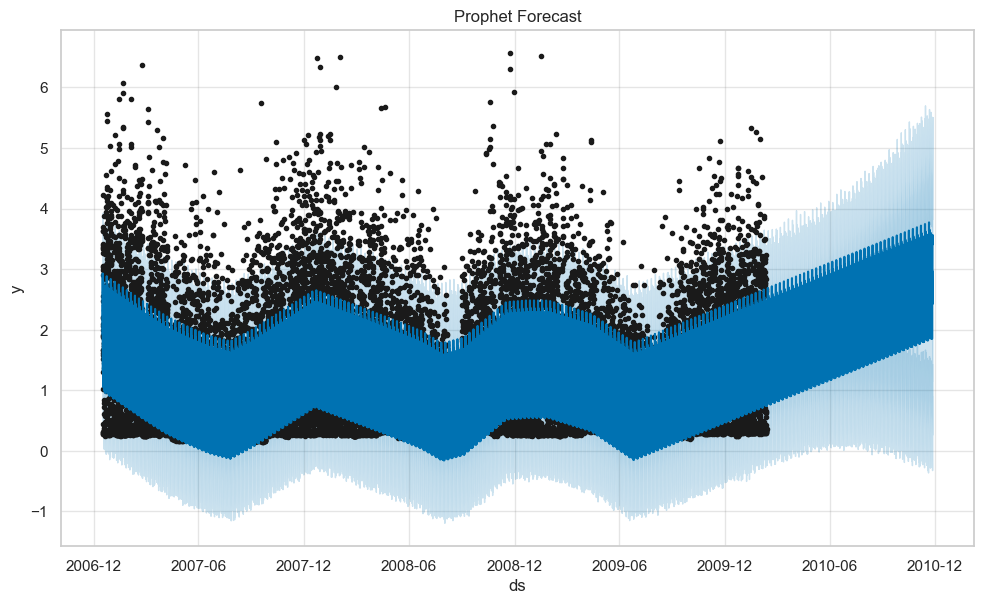

Prophet RMSE: 1.339


In [20]:
# Prepare dataframe for Prophet
prophet_df = df_features.reset_index()[['datetime','y']].rename(columns={'datetime':'ds'})

# Train-test split
prophet_train = prophet_df.iloc[:train_size]
prophet_test = prophet_df.iloc[train_size:]

# Fit Prophet model
prophet_model = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=False)
prophet_model.fit(prophet_train)

# Forecast
future = prophet_model.make_future_dataframe(periods=len(prophet_test), freq='H')
forecast = prophet_model.predict(future)

# Plot
prophet_model.plot(forecast)
plt.title('Prophet Forecast')
plt.show()

# Evaluate
prophet_pred = forecast['yhat'].iloc[-len(prophet_test):].values
prophet_rmse = np.sqrt(mean_squared_error(prophet_test['y'], prophet_pred))
print(f"Prophet RMSE: {prophet_rmse:.3f}")

## Step 8: XGBoost Model

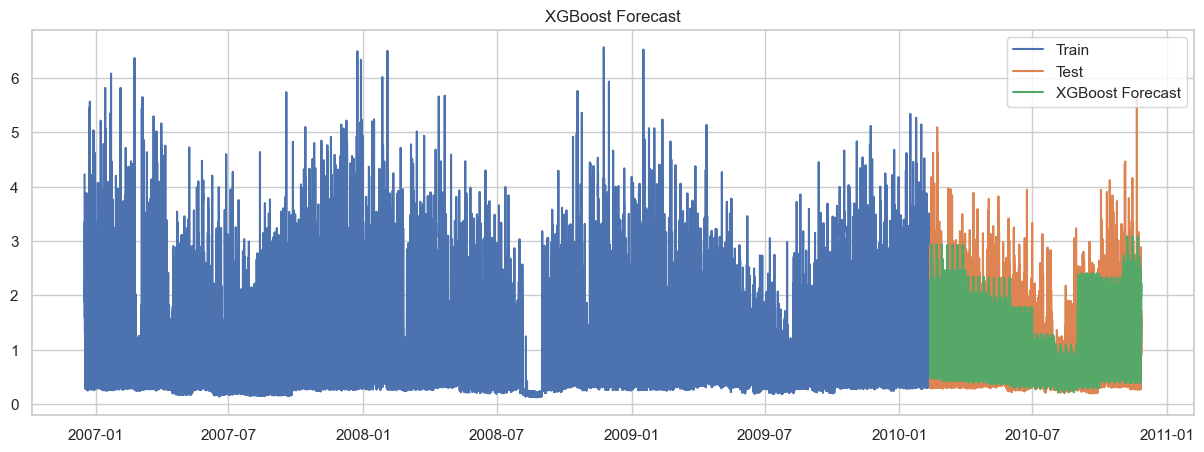

XGBoost RMSE: 0.607


In [21]:
# Fit XGBoost
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1)
xgb_model.fit(X_train, y_train)

# Forecast
xgb_pred = xgb_model.predict(X_test)

# Plot
plt.figure(figsize=(15,5))
plt.plot(train.index, y_train, label='Train')
plt.plot(test.index, y_test, label='Test')
plt.plot(test.index, xgb_pred, label='XGBoost Forecast')
plt.legend()
plt.title('XGBoost Forecast')
plt.show()

# Evaluate
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
print(f"XGBoost RMSE: {xgb_rmse:.3f}")

## Step 9: Comparison of Models

In [22]:
comparison = pd.DataFrame({
    'Model': ['ARIMA', 'Prophet', 'XGBoost'],
    'RMSE': [arima_rmse, prophet_rmse, xgb_rmse]
})

comparison

,Model,RMSE
0,ARIMA,0.876458
1,Prophet,1.338703
2,XGBoost,0.606983
